In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import matplotlib.pyplot as plt

In [10]:
# Define objective function for c=1.5
def f_rosenbrock(theta, c=1.5):
    """
    Rosenbrock 1D function:
    f(theta) = (1 - theta)^2 + c*(theta^2 - 1)^2
    """
    return (1 - theta)**2 + c * (theta**2 - 1)**2

def extract_params(filename):
    """Extract parameters from filename"""

    # For discrete files: c_X.X_results_initial_theta_Y_lr_Z_beta1_W_beta2_V.csv
    match_discrete = re.search(
        r'c_([\d.]+)_results_initial_theta_([-\d.]+)_lr_([\d.]+)_beta1_([\d.]+)_beta2_([\d.]+)\.csv',
        filename
    )
    if match_discrete:
        return {
            'c': float(match_discrete.group(1)),
            'initial_theta': float(match_discrete.group(2)),
            'initial_velocity': None,
            'lr': float(match_discrete.group(3)),
            'beta1': float(match_discrete.group(4)),
            'beta2': float(match_discrete.group(5))
        }

    # For 2nd order: second_order_c_X.X_initial_theta_Y_initial_velocity_Z_lr_W_beta1_V_beta2_U.csv
    match_2nd_order = re.search(
        r'second_order_c_([\d.]+)_initial_theta_([-\d.]+)_initial_velocity_([-\d.]+)_lr_([\d.]+)_beta1_([\d.]+)_beta2_([\d.]+)\.csv',
        filename
    )
    if match_2nd_order:
        return {
            'c': float(match_2nd_order.group(1)),
            'initial_theta': float(match_2nd_order.group(2)),
            'initial_velocity': float(match_2nd_order.group(3)),
            'lr': float(match_2nd_order.group(4)),
            'beta1': float(match_2nd_order.group(5)),
            'beta2': float(match_2nd_order.group(6))
        }


def compute_rho(alpha, beta1, beta2):
    term1 = alpha
    term2 = alpha**2 / (1 - beta1)**2
    term3 = alpha / (1 - beta2)
    rho = max(term1, term2, term3)
    return rho, term1, term2, term3

def exp_plus_floor(t, A, rho, B):
    return A * np.exp(-rho * t) + B

In [ ]:
# Configuration: theta_initial = -1.5, fixed betas
target_initial_theta = -1.5
target_beta1 = 0.99
target_beta2 = 0.999
c_value = 0
f_star = -3.73039
target_initial_velocity = 1.0

T_horizon = 700

# Continuous integration uses substeps h = alpha/5
SUBSTEP_FACTOR = 5  # dt_continuous = alpha / SUBSTEP_FACTOR

# Directories
results_dir = Path("results")
results_1st_order_dir = Path("results_1rst_order")
results_2nd_order_dir = Path("results_2nd_order")

In [12]:
# Read ALL discrete files
discrete_data_dict = {}
discrete_files = list(results_dir.glob("*.csv"))

for csv_file in discrete_files:
    params = extract_params(str(csv_file))
    if (params and
        params['c'] == c_value and
        params['initial_theta'] == target_initial_theta and
        params['beta1'] == target_beta1 and
        params['beta2'] == target_beta2):
        lr = params['lr']
        discrete_data_dict[lr] = pd.read_csv(csv_file)
        print(f"Discrete file found: {csv_file.name}, lr={lr}")

# Read 2nd order files
results_2nd_order = {}
continuous_2nd_files = list(results_2nd_order_dir.glob("*.csv"))

for csv_file in continuous_2nd_files:
    params = extract_params(str(csv_file))
    if (params and
        params['c'] == c_value and
        params['initial_theta'] == target_initial_theta and
        params['initial_velocity'] == target_initial_velocity and  # NUEVA LÍNEA
        params['beta1'] == target_beta1 and
        params['beta2'] == target_beta2):
        lr = params['lr']
        v0 = params['initial_velocity']

        if lr not in results_2nd_order:
            results_2nd_order[lr] = {}
        results_2nd_order[lr][v0] = pd.read_csv(csv_file)
        print(f"2nd order file found: {csv_file.name}, lr={lr}, v0={v0}")

Discrete file found: c_0.0_results_initial_theta_-1.5_lr_0.0005_beta1_0.99_beta2_0.999.csv, lr=0.0005
Discrete file found: c_0.0_results_initial_theta_-1.5_lr_0.01_beta1_0.99_beta2_0.999.csv, lr=0.01
Discrete file found: c_0.0_results_initial_theta_-1.5_lr_0.005_beta1_0.99_beta2_0.999.csv, lr=0.005
Discrete file found: c_0.0_results_initial_theta_-1.5_lr_0.05_beta1_0.99_beta2_0.999.csv, lr=0.05
Discrete file found: c_0.0_results_initial_theta_-1.5_lr_0.001_beta1_0.99_beta2_0.999.csv, lr=0.001
Discrete file found: c_0.0_results_initial_theta_-1.5_lr_0.1_beta1_0.99_beta2_0.999.csv, lr=0.1
2nd order file found: second_order_c_0.0_initial_theta_-1.5_initial_velocity_1.0_lr_0.1_beta1_0.99_beta2_0.999.csv, lr=0.1, v0=1.0
2nd order file found: second_order_c_0.0_initial_theta_-1.5_initial_velocity_1.0_lr_0.001_beta1_0.99_beta2_0.999.csv, lr=0.001, v0=1.0
2nd order file found: second_order_c_0.0_initial_theta_-1.5_initial_velocity_1.0_lr_0.005_beta1_0.99_beta2_0.999.csv, lr=0.005, v0=1.0
2nd o

Global optimum: θ* = 1.0, f* = 0.0

Learning rates to analyze (≤ 0.1):
  Discrete: [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
  Continuous: [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]

Discrete:
  α=0.0005, ρ=0.500000, ρ²=0.25000000, θ_final=0.999999, Φ_final=2.938181e-13
  α=0.0010, ρ=1.000000, ρ²=1.00000000, θ_final=1.000009, Φ_final=7.383432e-11
  α=0.0050, ρ=5.000000, ρ²=25.00000000, θ_final=0.996210, Φ_final=1.436320e-05
  α=0.0100, ρ=10.000000, ρ²=100.00000000, θ_final=0.999457, Φ_final=2.951829e-07
  α=0.0500, ρ=50.000000, ρ²=2500.00000000, θ_final=0.999019, Φ_final=9.627419e-07
  α=0.1000, ρ=100.000000, ρ²=10000.00000000, θ_final=1.000547, Φ_final=2.995851e-07

Continuous (v₀=1.0):
  α=0.0005, ρ=0.500000, ρ²=0.25000000, θ_final=0.999999, Φ_final=2.836732e-13
  α=0.0010, ρ=1.000000, ρ²=1.00000000, θ_final=1.000009, Φ_final=7.814117e-11
  α=0.0050, ρ=5.000000, ρ²=25.00000000, θ_final=0.996281, Φ_final=1.383006e-05
  α=0.0100, ρ=10.000000, ρ²=100.00000000, θ_final=0.999178, Φ_final=6.760

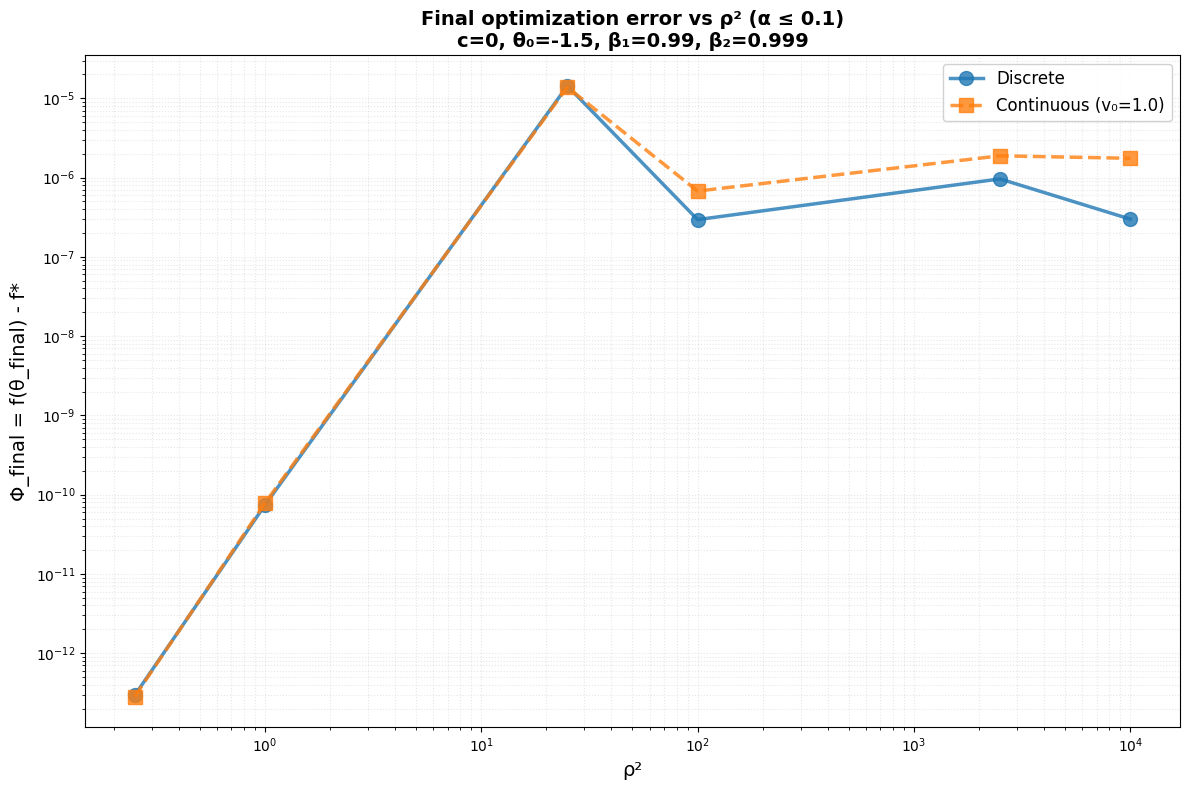


SUMMARY: Final Φ vs ρ²

Discrete:
  α=0.0005, ρ²=0.25000000 → Φ_final=2.938181e-13
  α=0.0010, ρ²=1.00000000 → Φ_final=7.383432e-11
  α=0.0050, ρ²=25.00000000 → Φ_final=1.436320e-05
  α=0.0100, ρ²=100.00000000 → Φ_final=2.951829e-07
  α=0.0500, ρ²=2500.00000000 → Φ_final=9.627419e-07
  α=0.1000, ρ²=10000.00000000 → Φ_final=2.995851e-07

Continuous (v₀=1.0):
  α=0.0005, ρ²=0.25000000 → Φ_final=2.836732e-13
  α=0.0010, ρ²=1.00000000 → Φ_final=7.814117e-11
  α=0.0050, ρ²=25.00000000 → Φ_final=1.383006e-05
  α=0.0100, ρ²=100.00000000 → Φ_final=6.760823e-07
  α=0.0500, ρ²=2500.00000000 → Φ_final=1.882839e-06
  α=0.1000, ρ²=10000.00000000 → Φ_final=1.752392e-06


In [13]:
# Filter learning rates <= 0.01
max_lr = 0.1
alphas_to_plot_discrete = [lr for lr in sorted(discrete_data_dict.keys()) if lr <= max_lr]
alphas_to_plot_continuous = [lr for lr in sorted(results_2nd_order.keys()) 
                              if lr <= max_lr and 1.0 in results_2nd_order[lr]]

# Optimal value f* (for Rosenbrock 1D with c=4, the global optimum is at theta=1)
theta_star = 1.0
f_star = f_rosenbrock(theta_star, c=c_value)  # Should be 0

print(f"Global optimum: θ* = {theta_star}, f* = {f_star}")
print(f"\nLearning rates to analyze (≤ {max_lr}):")
print(f"  Discrete: {alphas_to_plot_discrete}")
print(f"  Continuous: {alphas_to_plot_continuous}")

# Collect data for discrete
rho_squared_discrete = []
phi_final_discrete = []

print("\nDiscrete:")
for lr in alphas_to_plot_discrete:
    df = discrete_data_dict[lr]
    rho, _, _, _ = compute_rho(lr, target_beta1, target_beta2)
    rho_sq = rho**2
    
    # Get final theta value
    theta_final = df['theta_history'].iloc[-1]
    phi_final = f_rosenbrock(theta_final, c=c_value) - f_star
    
    rho_squared_discrete.append(rho_sq)
    phi_final_discrete.append(phi_final)
    print(f"  α={lr:.4f}, ρ={rho:.6f}, ρ²={rho_sq:.8f}, θ_final={theta_final:.6f}, Φ_final={phi_final:.6e}")

# Collect data for continuous
rho_squared_continuous = []
phi_final_continuous = []

print("\nContinuous (v₀=1.0):")
for lr in alphas_to_plot_continuous:
    df = results_2nd_order[lr][1.0]
    rho, _, _, _ = compute_rho(lr, target_beta1, target_beta2)
    rho_sq = rho**2
    
    # Get final theta value
    theta_final = df['theta'].iloc[-1] if 'theta' in df.columns else df['theta_history'].iloc[-1]
    phi_final = f_rosenbrock(theta_final, c=c_value) - f_star
    
    rho_squared_continuous.append(rho_sq)
    phi_final_continuous.append(phi_final)
    print(f"  α={lr:.4f}, ρ={rho:.6f}, ρ²={rho_sq:.8f}, θ_final={theta_final:.6f}, Φ_final={phi_final:.6e}")

# Create the plot
plt.figure(figsize=(12, 8))

plt.plot(rho_squared_discrete, phi_final_discrete, 'o-', label='Discrete', 
         linewidth=2.5, markersize=10, alpha=0.8)
plt.plot(rho_squared_continuous, phi_final_continuous, 's--', label='Continuous (v₀=1.0)', 
         linewidth=2.5, markersize=10, alpha=0.8)

plt.xlabel('ρ²', fontsize=14)
plt.ylabel('Φ_final = f(θ_final) - f*', fontsize=14)
plt.title(f'Final optimization error vs ρ² (α ≤ {max_lr})\n' + 
          f'c={c_value}, θ₀={target_initial_theta}, β₁={target_beta1}, β₂={target_beta2}', 
          fontsize=14, fontweight='bold')
plt.yscale('log')
plt.xscale('log')
plt.grid(True, alpha=0.3, which='both', linestyle=':')
plt.legend(fontsize=12, loc='best', framealpha=0.9)
plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*80)
print("SUMMARY: Final Φ vs ρ²")
print("="*80)
print("\nDiscrete:")
for lr, rho_sq, phi in zip(alphas_to_plot_discrete, rho_squared_discrete, phi_final_discrete):
    print(f"  α={lr:.4f}, ρ²={rho_sq:.8f} → Φ_final={phi:.6e}")

print("\nContinuous (v₀=1.0):")
for lr, rho_sq, phi in zip(alphas_to_plot_continuous, rho_squared_continuous, phi_final_continuous):
    print(f"  α={lr:.4f}, ρ²={rho_sq:.8f} → Φ_final={phi:.6e}")

T_horizon = 70.0
SUBSTEP_FACTOR = 5
delta = 1 (delta_factor=10 * max(alpha))
tail_window = 1.0
Learning rates to plot (≤ 0.1): [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]

Estimated plateau model: Phi_final ≈ a + b*rho^2
  a_hat = -7.291000e-05
  b_hat = 3.161058e-08
  Using B(rho) = a_hat + b_hat*rho^2 in the bias-corrected plot.



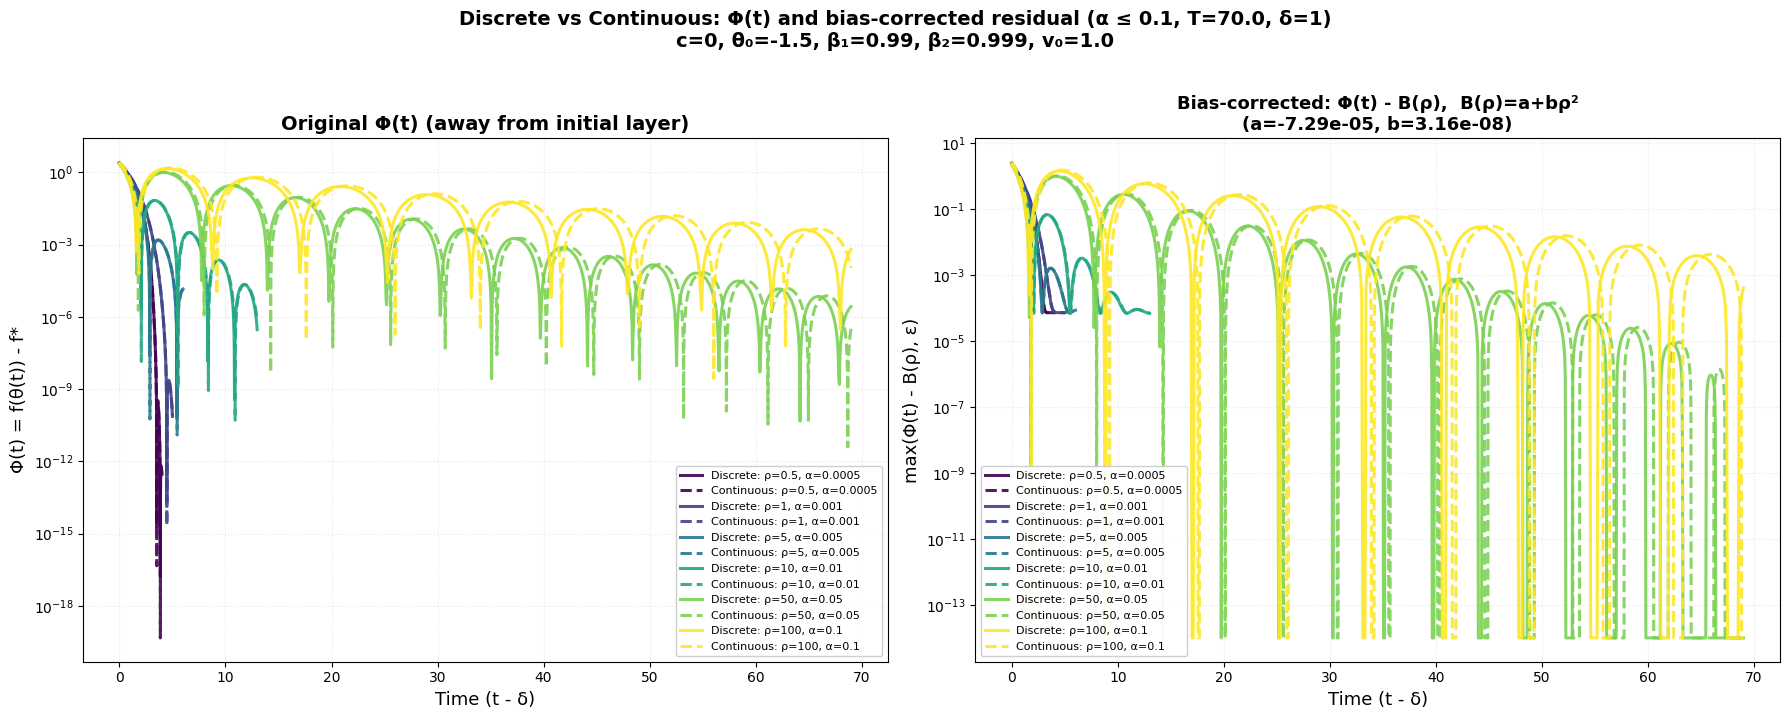

Bias values B(ρ) = a_hat + b_hat ρ²:
  α=0.0005: ρ=0.500000, B(ρ)=-7.290210e-05
  α=0.0010: ρ=1.000000, B(ρ)=-7.287839e-05
  α=0.0050: ρ=5.000000, B(ρ)=-7.211974e-05
  α=0.0100: ρ=10.000000, B(ρ)=-6.974895e-05
  α=0.0500: ρ=50.000000, B(ρ)=6.116451e-06
  α=0.1000: ρ=100.000000, B(ρ)=2.431958e-04


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ----------------------------
# Config
# ----------------------------
max_lr = 0.1
T_horizon = 700.0

# "Initial layer" cutoff (physical time). Must satisfy alpha < delta for all plotted alphas.
# A safe default: delta = delta_factor * max(alpha)
delta_factor = 10
tail_window = 1.0              # seconds used to estimate "final" value (avg over [T-tail_window, T])
eps = 1e-14                    # for log plots
show_alpha_in_label = True     # set False to reduce legend clutter

# ----------------------------
# Select alphas that exist in both discrete and continuous results
# ----------------------------
alphas_to_plot = sorted([
    lr for lr in discrete_data_dict.keys()
    if lr <= max_lr and lr in results_2nd_order and 1.0 in results_2nd_order[lr]
])

if len(alphas_to_plot) == 0:
    raise ValueError("No learning rates found that satisfy the filters (max_lr & availability in results_2nd_order).")

# Choose delta in physical time
delta = delta_factor * max(alphas_to_plot)  # guarantees alpha < delta for all lrs in the list

# ----------------------------
# Problem optimum f*
# ----------------------------
theta_star = 1.0
f_star = f_rosenbrock(theta_star, c=c_value)

print(f"T_horizon = {T_horizon}")
print(f"SUBSTEP_FACTOR = {SUBSTEP_FACTOR}")
print(f"delta = {delta:.6g} (delta_factor={delta_factor} * max(alpha))")
print(f"tail_window = {tail_window}")
print(f"Learning rates to plot (≤ {max_lr}): {alphas_to_plot}")

# ----------------------------
# Helper: compute Phi(t) for discrete/continuous (with time masks)
# ----------------------------
def compute_phi_time_discrete(lr):
    df = discrete_data_dict[lr]
    theta = df["theta_history"].values
    t = np.arange(len(theta)) * lr
    mask = t <= T_horizon
    t = t[mask]
    theta = theta[mask]
    phi = np.array([f_rosenbrock(th, c=c_value) - f_star for th in theta])
    return t, phi

def compute_phi_time_continuous(lr):
    df = results_2nd_order[lr][1.0]
    dt = lr / SUBSTEP_FACTOR
    theta = df["theta"].values if "theta" in df.columns else df["theta_history"].values
    t = np.arange(len(theta)) * dt
    mask = t <= T_horizon
    t = t[mask]
    theta = theta[mask]
    phi = np.array([f_rosenbrock(th, c=c_value) - f_star for th in theta])
    return t, phi

# ----------------------------
# Estimate B(rho) = a + b*rho^2 via weighted least squares (more stable than mean(phi/rho^2))
# Use a "final Phi" estimated from the tail average, not just last iterate.
# ----------------------------
rho_sq_list = []
phi_final_list = []

for lr in alphas_to_plot:
    rho, _, _, _ = compute_rho(lr, target_beta1, target_beta2)
    rho_sq = rho**2

    t_d, phi_d = compute_phi_time_discrete(lr)
    # tail average over [T - tail_window, T]
    tail_mask = t_d >= max(T_horizon - tail_window, 0.0)
    if not np.any(tail_mask):
        # fallback to last point if horizon is tiny
        phi_final = phi_d[-1]
    else:
        phi_final = float(np.mean(phi_d[tail_mask]))

    rho_sq_list.append(rho_sq)
    phi_final_list.append(phi_final)

rho_sq_arr = np.array(rho_sq_list, dtype=float)
phi_f_arr = np.array(phi_final_list, dtype=float)

# Guard against any accidental zeros (shouldn't happen, but safe)
pos = rho_sq_arr > 0
rho_sq_arr = rho_sq_arr[pos]
phi_f_arr = phi_f_arr[pos]

# Weighted LS: minimize sum w_i (a + b*rho^2 - phi_final)^2
# Use weights that downweight tiny rho^2 (they can dominate numerically)
w = rho_sq_arr / np.max(rho_sq_arr)
W = np.sqrt(w)

A = np.vstack([np.ones_like(rho_sq_arr), rho_sq_arr]).T
A_w = A * W[:, None]
y_w = phi_f_arr * W

a_hat, b_hat = np.linalg.lstsq(A_w, y_w, rcond=None)[0]
print(f"\nEstimated plateau model: Phi_final ≈ a + b*rho^2")
print(f"  a_hat = {a_hat:.6e}")
print(f"  b_hat = {b_hat:.6e}")
print(f"  Using B(rho) = a_hat + b_hat*rho^2 in the bias-corrected plot.\n")

# ----------------------------
# Plotting
# ----------------------------
colors = cm.viridis(np.linspace(0, 1, len(alphas_to_plot)))
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

# --- LEFT: Original Phi(t) ---
ax = axes[0]
for i, lr in enumerate(alphas_to_plot):
    rho, _, _, _ = compute_rho(lr, target_beta1, target_beta2)
    color = colors[i]

    t_d, phi_d = compute_phi_time_discrete(lr)
    t_c, phi_c = compute_phi_time_continuous(lr)

    # Plot only "away from initial layer"
    md = t_d >= delta
    mc = t_c >= delta

    label_base = f"ρ={rho:.4g}" + (f", α={lr:.4g}" if show_alpha_in_label else "")
    ax.plot(t_d[md] - delta, phi_d[md], "-",  color=color, lw=2.2, alpha=0.9, label=f"Discrete: {label_base}")
    ax.plot(t_c[mc] - delta, phi_c[mc], "--", color=color, lw=2.2, alpha=0.9, label=f"Continuous: {label_base}")

ax.set_title("Original Φ(t) (away from initial layer)", fontsize=14, fontweight="bold")
ax.set_xlabel("Time (t - δ)", fontsize=13)
ax.set_ylabel("Φ(t) = f(θ(t)) - f*", fontsize=13)
ax.set_yscale("log")
ax.grid(True, alpha=0.3, which="both", linestyle=":")

# --- RIGHT: Bias-corrected Phi(t) - B(rho) with B(rho)=a+b*rho^2 ---
ax = axes[1]
for i, lr in enumerate(alphas_to_plot):
    rho, _, _, _ = compute_rho(lr, target_beta1, target_beta2)
    color = colors[i]
    B_rho = a_hat + b_hat * rho**2  # plateau estimate

    t_d, phi_d = compute_phi_time_discrete(lr)
    t_c, phi_c = compute_phi_time_continuous(lr)

    md = t_d >= delta
    mc = t_c >= delta

    # Residuals (clip to eps so semilog works without hiding points)
    res_d = np.maximum(phi_d - B_rho, eps)
    res_c = np.maximum(phi_c - B_rho, eps)

    label_base = f"ρ={rho:.4g}" + (f", α={lr:.4g}" if show_alpha_in_label else "")
    ax.plot(t_d[md] - delta, res_d[md], "-",  color=color, lw=2.2, alpha=0.9, label=f"Discrete: {label_base}")
    ax.plot(t_c[mc] - delta, res_c[mc], "--", color=color, lw=2.2, alpha=0.9, label=f"Continuous: {label_base}")

ax.set_title(f"Bias-corrected: Φ(t) - B(ρ),  B(ρ)=a+bρ²\n(a={a_hat:.2e}, b={b_hat:.2e})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Time (t - δ)", fontsize=13)
ax.set_ylabel("max(Φ(t) - B(ρ), ε)", fontsize=13)
ax.set_yscale("log")
ax.grid(True, alpha=0.3, which="both", linestyle=":")

# Legends: keep them readable
for ax in axes:
    ax.legend(fontsize=8, loc="best", framealpha=0.95, ncol=1)

fig.suptitle(
    f"Discrete vs Continuous: Φ(t) and bias-corrected residual (α ≤ {max_lr}, T={T_horizon}, δ={delta:.3g})\n"
    f"c={c_value}, θ₀={target_initial_theta}, β₁={target_beta1}, β₂={target_beta2}, v₀=1.0",
    fontsize=14, y=1.02, fontweight="bold"
)
plt.tight_layout()
plt.show()

# ----------------------------
# Print B(rho) values
# ----------------------------
print("Bias values B(ρ) = a_hat + b_hat ρ²:")
for lr in alphas_to_plot:
    rho, _, _, _ = compute_rho(lr, target_beta1, target_beta2)
    B_rho = a_hat + b_hat * rho**2
    print(f"  α={lr:.4f}: ρ={rho:.6f}, B(ρ)={B_rho:.6e}")


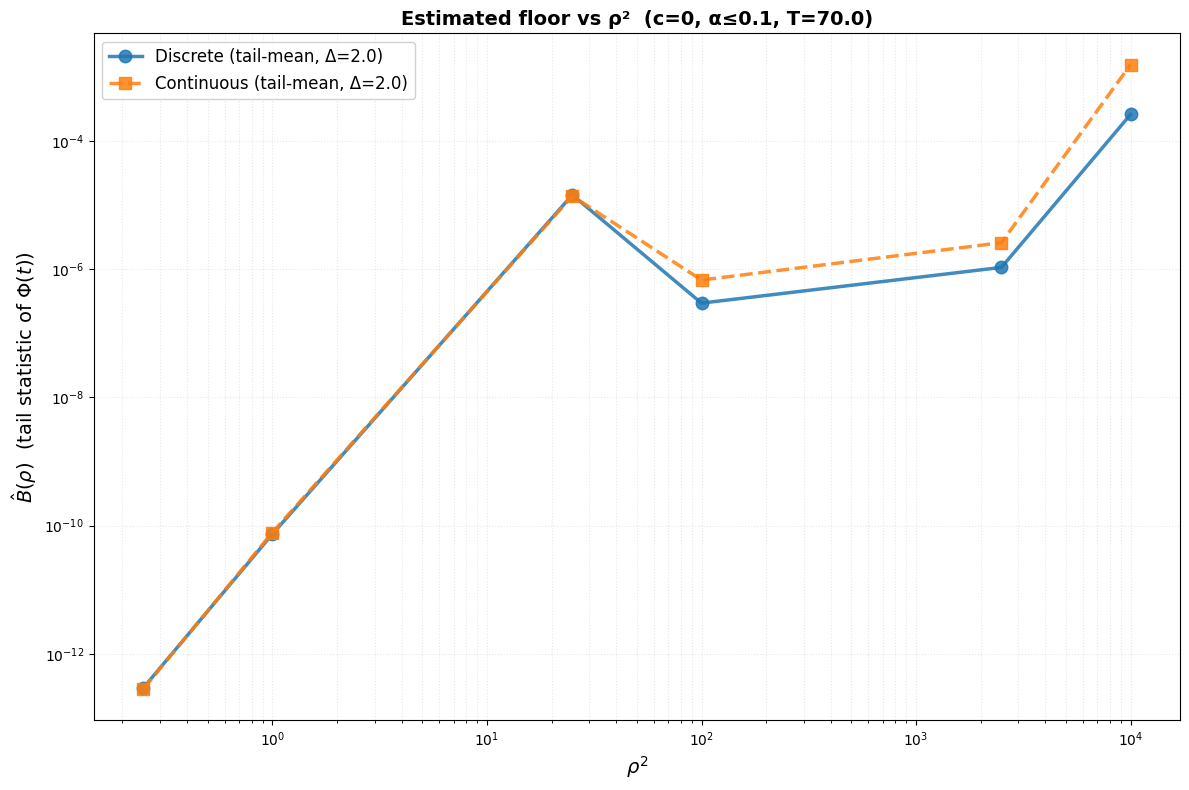

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Config
# ----------------------------
max_lr = 0.1          # prueba también 0.01 si quieres un régimen más "limpio"
T_horizon = 700.0
SUBSTEP_FACTOR = 5
tail_window = 2.0     # usa 1.0–5.0 según T_horizon

# Global optimum for c=0
theta_star = 1.0
f_star = f_rosenbrock(theta_star, c=c_value)   # para c=0: 0

def tail_stat(t, phi, T, window=2.0, mode="mean"):
    """mode: 'mean' o 'min' sobre [T-window, T]."""
    m = t >= max(T - window, 0.0)
    if not np.any(m):
        return float(phi[-1])
    if mode == "min":
        return float(np.min(phi[m]))
    return float(np.mean(phi[m]))

def phi_time_discrete(lr, T):
    df = discrete_data_dict[lr]
    theta = df["theta_history"].values
    t = np.arange(len(theta)) * lr
    m = t <= T
    t = t[m]
    theta = theta[m]
    phi = np.array([f_rosenbrock(th, c=c_value) - f_star for th in theta])
    return t, phi

def phi_time_continuous(lr, T):
    df = results_2nd_order[lr][1.0]
    dt = lr / SUBSTEP_FACTOR
    theta = df["theta"].values if "theta" in df.columns else df["theta_history"].values
    t = np.arange(len(theta)) * dt
    m = t <= T
    t = t[m]
    theta = theta[m]
    phi = np.array([f_rosenbrock(th, c=c_value) - f_star for th in theta])
    return t, phi

# ----------------------------
# Alphas disponibles
# ----------------------------
alphas_disc = [lr for lr in sorted(discrete_data_dict.keys()) if lr <= max_lr]
alphas_cont = [lr for lr in sorted(results_2nd_order.keys())
               if lr <= max_lr and 1.0 in results_2nd_order[lr]]

# ----------------------------
# Recolecta floors (tail mean/min) vs rho^2
# ----------------------------
rho2_disc, floor_disc_mean, floor_disc_min = [], [], []
rho2_cont, floor_cont_mean, floor_cont_min = [], [], []

for lr in alphas_disc:
    rho, _, _, _ = compute_rho(lr, target_beta1, target_beta2)
    t, phi = phi_time_discrete(lr, T_horizon)
    rho2_disc.append(rho**2)
    floor_disc_mean.append(tail_stat(t, phi, T_horizon, tail_window, "mean"))
    floor_disc_min.append(tail_stat(t, phi, T_horizon, tail_window, "min"))

for lr in alphas_cont:
    rho, _, _, _ = compute_rho(lr, target_beta1, target_beta2)
    t, phi = phi_time_continuous(lr, T_horizon)
    rho2_cont.append(rho**2)
    floor_cont_mean.append(tail_stat(t, phi, T_horizon, tail_window, "mean"))
    floor_cont_min.append(tail_stat(t, phi, T_horizon, tail_window, "min"))

# Ordena por rho^2 para que la línea no "salte"
def sort_xy(x, y):
    idx = np.argsort(x)
    return np.array(x)[idx], np.array(y)[idx]

xD, yD = sort_xy(rho2_disc, floor_disc_mean)  # tail mean (discrete)
xC, yC = sort_xy(rho2_cont, floor_cont_mean)  # tail mean (continuous)

plt.figure(figsize=(12, 8))
plt.plot(xD, yD, "o-",  lw=2.5, ms=9, alpha=0.85, label=f"Discrete (tail-mean, Δ={tail_window})")
plt.plot(xC, yC, "s--", lw=2.5, ms=9, alpha=0.85, label=f"Continuous (tail-mean, Δ={tail_window})")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\rho^2$", fontsize=14)
plt.ylabel(r"$\hat B(\rho)$  (tail statistic of $\Phi(t)$)", fontsize=14)
plt.title(f"Estimated floor vs ρ²  (c={c_value}, α≤{max_lr}, T={T_horizon})", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3, which="both", linestyle=":")
plt.legend(fontsize=12, loc="best", framealpha=0.9)
plt.tight_layout()
plt.show()


Fit floor: B(rho) ≈ k*rho^2 with k = 2.441044e-08  (tail_window=2.0)


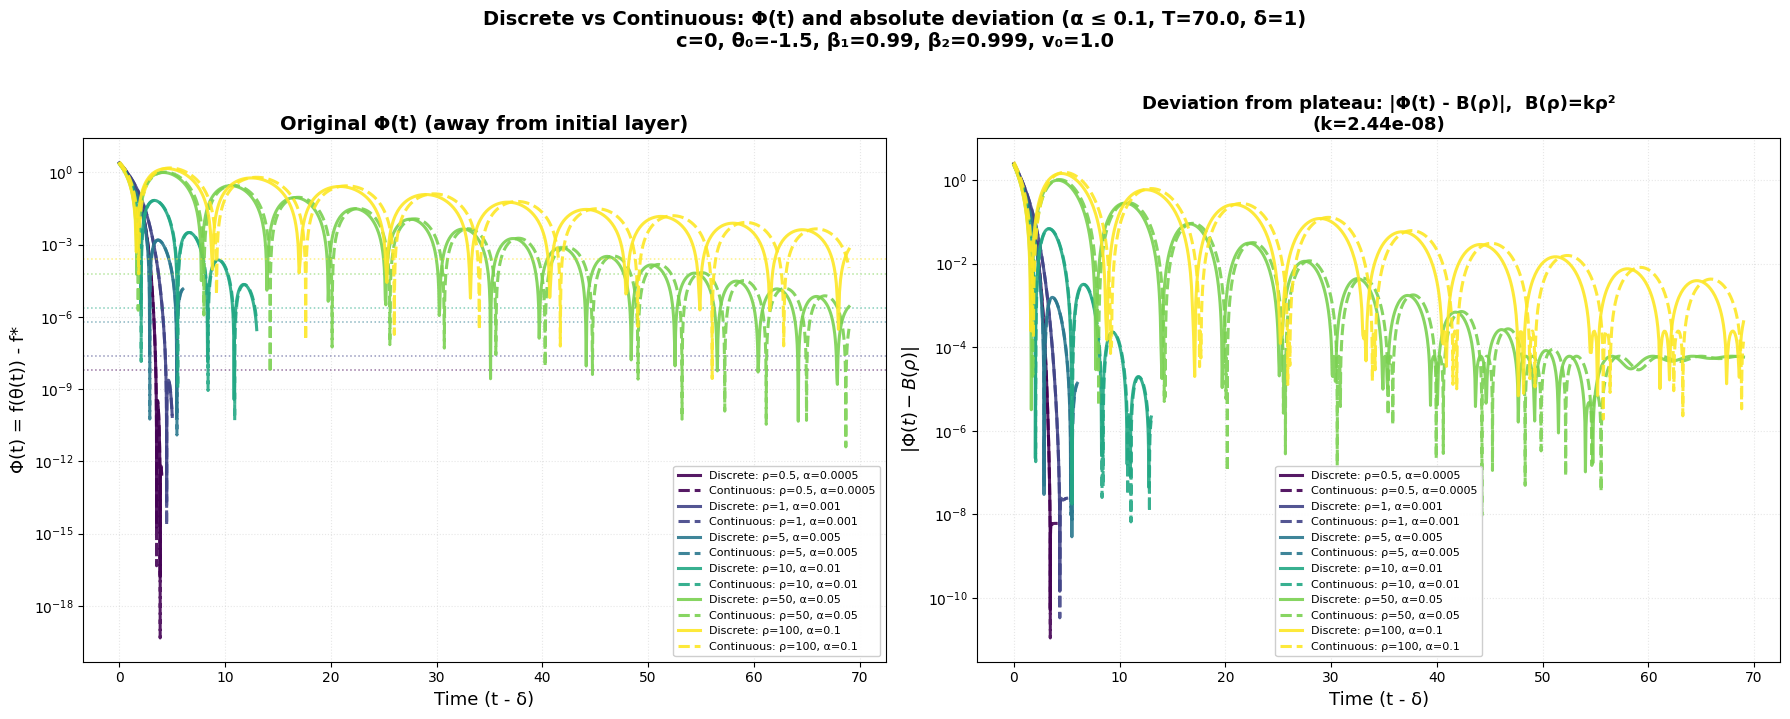

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

max_lr = 0.1
T_horizon = 700.0
delta_factor = 10
tail_window = 2.0
eps = 1e-14
show_alpha_in_label = True

alphas_to_plot = sorted([
    lr for lr in discrete_data_dict.keys()
    if lr <= max_lr and lr in results_2nd_order and 1.0 in results_2nd_order[lr]
])
delta = delta_factor * max(alphas_to_plot)

# f*
theta_star = 1.0
f_star = f_rosenbrock(theta_star, c=c_value)

def compute_phi_time_discrete(lr):
    df = discrete_data_dict[lr]
    theta = df["theta_history"].values
    t = np.arange(len(theta)) * lr
    m = t <= T_horizon
    t = t[m]; theta = theta[m]
    phi = np.array([f_rosenbrock(th, c=c_value) - f_star for th in theta])
    return t, phi

def compute_phi_time_continuous(lr):
    df = results_2nd_order[lr][1.0]
    dt = lr / SUBSTEP_FACTOR
    theta = df["theta"].values if "theta" in df.columns else df["theta_history"].values
    t = np.arange(len(theta)) * dt
    m = t <= T_horizon
    t = t[m]; theta = theta[m]
    phi = np.array([f_rosenbrock(th, c=c_value) - f_star for th in theta])
    return t, phi

def tail_mean_floor(t, phi, T, window):
    m = t >= max(T - window, 0.0)
    return float(np.mean(phi[m])) if np.any(m) else float(phi[-1])

# --- Ajuste k en B(rho) ≈ k*rho^2 (sin intercepto, k>=0) usando tail-mean del discreto ---
rho2_list, floor_list = [], []
for lr in alphas_to_plot:
    rho, _, _, _ = compute_rho(lr, target_beta1, target_beta2)
    t_d, phi_d = compute_phi_time_discrete(lr)
    rho2_list.append(rho**2)
    floor_list.append(tail_mean_floor(t_d, phi_d, T_horizon, tail_window))

rho2_arr = np.array(rho2_list)
floor_arr = np.array(floor_list)

# LS through origin: minimize ||k*rho2 - floor||^2  => k = (rho2·floor)/(rho2·rho2)
k_hat = float(np.dot(rho2_arr, floor_arr) / np.dot(rho2_arr, rho2_arr))
k_hat = max(k_hat, 0.0)

print(f"Fit floor: B(rho) ≈ k*rho^2 with k = {k_hat:.6e}  (tail_window={tail_window})")

# --- Plots ---
colors = cm.viridis(np.linspace(0, 1, len(alphas_to_plot)))
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

# LEFT: Phi(t)
ax = axes[0]
for i, lr in enumerate(alphas_to_plot):
    rho, _, _, _ = compute_rho(lr, target_beta1, target_beta2)
    color = colors[i]
    t_d, phi_d = compute_phi_time_discrete(lr)
    t_c, phi_c = compute_phi_time_continuous(lr)

    md = t_d >= delta
    mc = t_c >= delta

    label_base = f"ρ={rho:.4g}" + (f", α={lr:.4g}" if show_alpha_in_label else "")
    ax.plot(t_d[md] - delta, phi_d[md], "-",  color=color, lw=2.2, alpha=0.9, label=f"Discrete: {label_base}")
    ax.plot(t_c[mc] - delta, phi_c[mc], "--", color=color, lw=2.2, alpha=0.9, label=f"Continuous: {label_base}")

    # draw fitted plateau line
    B_rho = k_hat * (rho**2)
    ax.axhline(B_rho, color=color, linestyle=":", linewidth=1.1, alpha=0.55)

ax.set_title("Original Φ(t) (away from initial layer)", fontsize=14, fontweight="bold")
ax.set_xlabel("Time (t - δ)", fontsize=13)
ax.set_ylabel("Φ(t) = f(θ(t)) - f*", fontsize=13)
ax.set_yscale("log")
ax.grid(True, alpha=0.3, which="both", linestyle=":")

# RIGHT: absolute residual |Phi - B|
ax = axes[1]
for i, lr in enumerate(alphas_to_plot):
    rho, _, _, _ = compute_rho(lr, target_beta1, target_beta2)
    color = colors[i]
    B_rho = k_hat * (rho**2)

    t_d, phi_d = compute_phi_time_discrete(lr)
    t_c, phi_c = compute_phi_time_continuous(lr)

    md = t_d >= delta
    mc = t_c >= delta

    res_d = np.maximum(np.abs(phi_d - B_rho), eps)
    res_c = np.maximum(np.abs(phi_c - B_rho), eps)

    label_base = f"ρ={rho:.4g}" + (f", α={lr:.4g}" if show_alpha_in_label else "")
    ax.plot(t_d[md] - delta, res_d[md], "-",  color=color, lw=2.2, alpha=0.9, label=f"Discrete: {label_base}")
    ax.plot(t_c[mc] - delta, res_c[mc], "--", color=color, lw=2.2, alpha=0.9, label=f"Continuous: {label_base}")

ax.set_title(f"Deviation from plateau: |Φ(t) - B(ρ)|,  B(ρ)=kρ²\n(k={k_hat:.2e})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Time (t - δ)", fontsize=13)
ax.set_ylabel(r"$|\Phi(t)-B(\rho)|$", fontsize=13)
ax.set_yscale("log")
ax.grid(True, alpha=0.3, which="both", linestyle=":")

for ax in axes:
    ax.legend(fontsize=8, loc="best", framealpha=0.95, ncol=1)

fig.suptitle(
    f"Discrete vs Continuous: Φ(t) and absolute deviation (α ≤ {max_lr}, T={T_horizon}, δ={delta:.3g})\n"
    f"c={c_value}, θ₀={target_initial_theta}, β₁={target_beta1}, β₂={target_beta2}, v₀=1.0",
    fontsize=14, y=1.02, fontweight="bold"
)
plt.tight_layout()
plt.show()
